# CG-QAOA: QAOA guiado por restricciones en instancias de QOBLIB

**Problema:** conjunto independiente máximo (MIS), clase 07 de la *Quantum Optimization Benchmarking Library* (QOBLIB).

Extendemos al QAOA la idea del paper *Negation-forced amplitude amplification*: cada restricción se lee como una **condición negada** que *fuerza* variables dentro de la preparación del estado. El resultado es el **CG-QAOA** (*constraint-guided QAOA*), con tres piezas:

1. **Estado inicial** $|\psi_0\rangle=A_q|0\rangle$: preparación con condiciones negadas y una "moneda" sesgada $q$.
2. **Fase de costo** $e^{-i\gamma C}$, con $C(x)=-|x|$.
3. **Mezclador de Grover** $e^{-i\beta|\psi_0\rangle\langle\psi_0|}=A_q\,e^{-i\beta|0\rangle\langle0|}\,A_q^\dagger$ (Bärtschi y Eidenbenz).

Para MIS, todas las condiciones dicen "no ambos" ($\neg x_u\vee\neg x_v$). Una variable solo puede quedar forzada a 0, así que **nunca hay conflictos**: el soporte de $A_q|0\rangle$ es *exactamente* el conjunto de todos los conjuntos independientes, y el CG-QAOA **nunca sale del espacio factible**, a cualquier profundidad.

### Qué se demuestra y qué no
| Comparación | Resultado en este notebook |
|---|---|
| Contra el QAOA con penalizaciones (QUBO), la línea base de las submissions de QOBLIB | 100 % de factibilidad contra ~30–60 %, y razón de aproximación ~0.9 contra ~0.2–0.3, **a la misma profundidad $p$** |
| Contra el QAOA de Hadfield, que también preserva las restricciones | mejor en 4 de 6 subinstancias; Hadfield gana en `football` (y en `frb50` a $p=2$) |
| Contra muestrear de forma clásica la misma distribución $A_q$, a igual número de preparaciones | empate a $p=1$; entre 1.3× y 2.3× mayor $P(\text{óptimo})$ a $p=2$; con amplificación, **cuadráticamente menos preparaciones**: 15×–41× ($q=0.5$) y 2.7×–7× (mejor $q$ de cada uno) |
| Contra resolvedores clásicos de MIS | **sin ventaja**: 18 nodos se resuelven al instante en una computadora clásica |

Las instancias pequeñas de QOBLIB (`farm`, `kangaroo`) las resuelve la heurística voraz clásica. Por eso usamos **subinstancias de 18 nodos extraídas de grafos de QOBLIB** en las que esa heurística falla (`instances/qoblib/`, CC BY 4.0).

In [1]:
import sys, json, math, time
sys.path.insert(0, '..')
import numpy as np, matplotlib.pyplot as plt, networkx as nx
from scipy.optimize import minimize
from negsearch.qaoa_mis import read_gph, MIS, prep_biased
from negsearch.qaoa_circuits import prep_circuit, cg_qaoa, penalty_qaoa, hadfield_qaoa
QDIR = '../instances/qoblib/'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. La instancia

`karate-sub18` es un subgrafo inducido de 18 vértices del grafo `karate` de QOBLIB. Su conjunto independiente máximo tiene 10 vértices, pero la heurística voraz de grado mínimo solo encuentra 9.

18 vértices, 38 aristas | óptimo (fuerza bruta) = 10 | voraz grado-mínimo = 9
conjuntos independientes: 2771 de 2^18 = 262144  | óptimos: 1


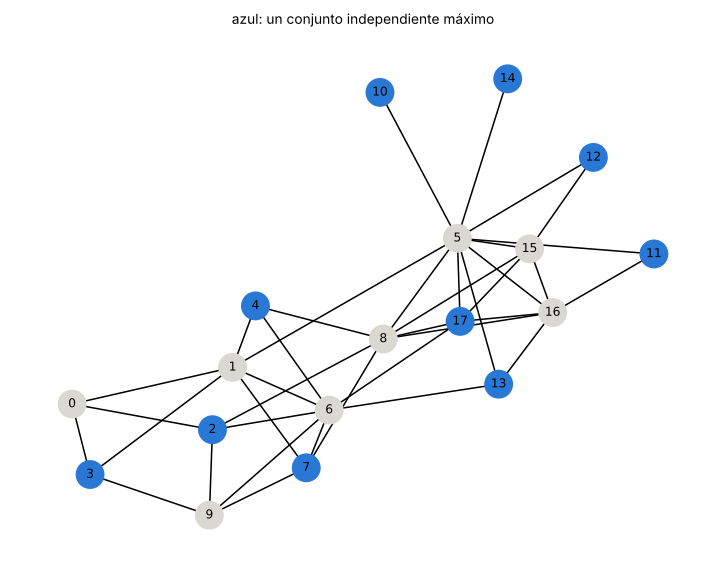

In [2]:
name = 'karate-sub18'
n, E = read_gph(QDIR + name + '.gph'); g = MIS(n, E)
order = sorted(range(n), key=lambda v: (len(g.N[v]), v))          # grado bajo primero (no usa la solución)
def greedy(order):
    S = set()
    for v in order:
        if not (g.N[v] & S): S.add(v)
    return S
print(f'{n} vértices, {len(E)} aristas | óptimo (fuerza bruta) = {g.opt} | voraz grado-mínimo = {len(greedy(order))}')
print(f'conjuntos independientes: {g.feas.sum()} de 2^{n} = {2**n}  | óptimos: {(g.feas & (g.size==g.opt)).sum()}')
G = nx.Graph(E); opt_set = [v for v in range(n) if g.bits[np.flatnonzero(g.feas & (g.size==g.opt))[0], v]]
nx.draw(G, nx.spring_layout(G, seed=3), node_color=['#2a78d6' if v in opt_set else '#d9d8d2' for v in range(n)],
        with_labels=True, node_size=320, font_size=8); plt.title('azul: un conjunto independiente máximo', fontsize=9); plt.show()

## 2. Condiciones negadas y la preparación $A_q$

Recorremos los vértices en orden $\pi$. Si algún vecino anterior ya está en el conjunto, la condición $\neg x_u\vee\neg x_v$ **fuerza** $x_v=0$. Si no, aplicamos una rotación $R_y$ que incluye a $v$ con probabilidad $q$. En el circuito es un $R_y$ multicontrolado por "todos los vecinos anteriores en 0".

**Lema (soporte exacto).** Para cualquier $q\in(0,1)$, $\operatorname{supp}A_q|0\rangle$ = {conjuntos independientes}.

*Prueba.* Un vértice solo entra si ningún vecino anterior está dentro, así que nunca se forma una arista: todo el soporte es factible. Para un conjunto independiente $S$, en el camino que lo sigue ningún vértice de $S$ queda forzado a 0, así que $S$ tiene amplitud $\prod_v\sqrt{q}^{[v\in S]}\sqrt{1-q}^{[v\notin S,\ v\text{ no forzado}]}>0$. ∎

Como el mezclador de Grover solo combina el estado actual con $|\psi_0\rangle$ y la fase de costo es diagonal, el CG-QAOA se queda en el espacio factible.

In [3]:
for q in (0.5, 0.9):
    psi0 = prep_biased(g, order, q); pr = np.abs(psi0)**2
    print(f'q={q}: P(infactible)={pr[~g.feas].sum():.1e} | conjuntos independientes con amplitud>0: {(pr[g.feas]>0).sum()} de {g.feas.sum()} | P(óptimo)={pr[g.feas & (g.size==g.opt)].sum():.4f}')

q=0.5: P(infactible)=0.0e+00 | conjuntos independientes con amplitud>0: 2771 de 2771 | P(óptimo)=0.0005
q=0.9: P(infactible)=0.0e+00 | conjuntos independientes con amplitud>0: 2771 de 2771 | P(óptimo)=0.0349


## 3. Las tres variantes de QAOA

| | Estado inicial | Costo | Mezclador |
|---|---|---|---|
| **Penalizaciones** (QUBO) | $|+\rangle^{\otimes n}$ | $-|x|+\lambda\sum_{(u,v)}x_ux_v$ | $\sum_v X_v$ |
| **Hadfield** (preserva restricciones) | $|0\rangle^{\otimes n}$ | $-|x|$ | $R_x$ en $v$ controlado por "vecinos en 0" |
| **CG-QAOA** (este trabajo) | $A_q|0\rangle$ | $-|x|$ | $A_q e^{-i\beta|0\rangle\langle0|}A_q^\dagger$ |

La simulación es exacta, por vector de estado sobre $2^{18}$ amplitudes. Los circuitos de Qiskit equivalentes, listos para hardware, están en `negsearch/qaoa_circuits.py` y se verificaron contra esta simulación.

In [4]:
def run(method, p, restarts=3, seed=0):
    rng = np.random.default_rng(seed); best = None
    if method == 'penalty':
        for lam in (2.0, 3.0):
            C = -g.size + lam * g.viol
            for _ in range(restarts):
                r = minimize(lambda x: float((np.abs(g.penalty_state(x, lam))**2 * C).sum()), rng.uniform(0, np.pi, 2*p), method='COBYLA', options={'maxiter': 250})
                m = g.metrics(g.penalty_state(r.x, lam))
                if best is None or m['ratio'] > best[0]['ratio']: best = (m, dict(lam=lam, x=r.x))
    elif method == 'hadfield':
        for _ in range(restarts):
            r = minimize(lambda x: -float((np.abs(g.hadfield_state(x))**2 * g.size).sum()), rng.uniform(0, np.pi, 2*p), method='COBYLA', options={'maxiter': 250})
            m = g.metrics(g.hadfield_state(r.x))
            if best is None or m['ratio'] > best[0]['ratio']: best = (m, dict(x=r.x))
    else:   # CG-QAOA, q variational (q = sigmoid(z))
        sig = lambda z: 1/(1+np.exp(-z))
        f = lambda x: -float((np.abs(g.gm_state(x[:-1], prep_biased(g, order, sig(x[-1]))))**2 * g.size).sum())
        for _ in range(restarts):
            r = minimize(f, np.r_[rng.uniform(0, np.pi, 2*p), 1.0], method='COBYLA', options={'maxiter': 250})
            q = sig(r.x[-1]); m = g.metrics(g.gm_state(r.x[:-1], prep_biased(g, order, q)))
            if best is None or m['ratio'] > best[0]['ratio']: best = (m, dict(q=q, x=r.x[:-1]))
    return best

t0 = time.time(); res = {k: run(k, 1) for k in ('penalty', 'hadfield', 'cg')}
q1 = res['cg'][1]['q']; prep_alone = g.metrics(prep_biased(g, order, q1))
print(f'(optimización p=1: {time.time()-t0:.0f} s)')
print(f"{'método':34s} {'P(factible)':>11s} {'razón':>7s} {'P(óptimo)':>10s}")
for lab, m in [('QAOA penalizaciones (λ=%g)' % res['penalty'][1]['lam'], res['penalty'][0]), ('QAOA Hadfield', res['hadfield'][0]),
               ('CG-QAOA (q=%.2f)' % q1, res['cg'][0]), ('clásico: muestrear A_q (q=%.2f)' % q1, prep_alone)]:
    print(f"{lab:34s} {m['p_feas']:11.3f} {m['ratio']:7.3f} {m['p_opt']:10.4f}")

(optimización p=1: 121 s)
método                             P(factible)   razón  P(óptimo)
QAOA penalizaciones (λ=2)                0.417   0.178     0.0001
QAOA Hadfield                            1.000   0.495     0.0008
CG-QAOA (q=0.97)                         1.000   0.904     0.0649
clásico: muestrear A_q (q=0.97)          1.000   0.883     0.0212


**A igual costo.** Una capa de CG-QAOA usa 3 preparaciones ($A$, $A^\dagger$, $A$). Con 3 muestras clásicas de $A_q$, la probabilidad de ver el óptimo es $1-(1-P)^3$:

In [5]:
P = prep_alone['p_opt']
print(f"CG-QAOA p=1: {res['cg'][0]['p_opt']:.3f}   vs   3 muestras clásicas: {1-(1-P)**3:.3f}   (empate esperado a p=1)")

CG-QAOA p=1: 0.065   vs   3 muestras clásicas: 0.062   (empate esperado a p=1)


## 4. Resultados en 8 instancias de QOBLIB ($p=1,2$)

Resultados precalculados con `experiments/cg_qaoa_experiments.py`: 6 subinstancias en las que la voraz falla ($p=1,2$), más las dos instancias completas pequeñas (`farm`, `kangaroo`, solo $p=1$), que la voraz resuelve y donde el $q$ variacional tiende a 1, es decir, a la propia voraz.

instancia                        p  factib.pen | razón: pen   Hadf   CG   | P(opt): pen    Hadf    CG     clás.A_q
karate-sub18                     1       0.50  |      0.20   0.50  0.90 |    0.0000  0.0008  0.065    0.021
karate-sub18                     2       0.67  |      0.30   0.80  0.92 |    0.0002  0.0000  0.212    0.032
chesapeake-sub18                 1       0.42  |      0.16   0.56  0.89 |    0.0001  0.0000  0.088    0.029
chesapeake-sub18                 2       0.32  |      0.14   0.78  0.91 |    0.0002  0.0000  0.256    0.041
frb50-23-3-sub18                 1       0.29  |      0.13   0.34  0.90 |    0.0001  0.0010  0.114    0.036
frb50-23-3-sub18                 2       0.48  |      0.18   1.00  0.92 |    0.0000  1.0000  0.285    0.041
C125-9-sub18                     1       0.33  |      0.15   0.46  0.91 |    0.0000  0.0000  0.049    0.016
C125-9-sub18                     2       0.57  |      0.30   0.73  0.92 |    0.0000  0.0244  0.195    0.030
hamming6-4-sub18     

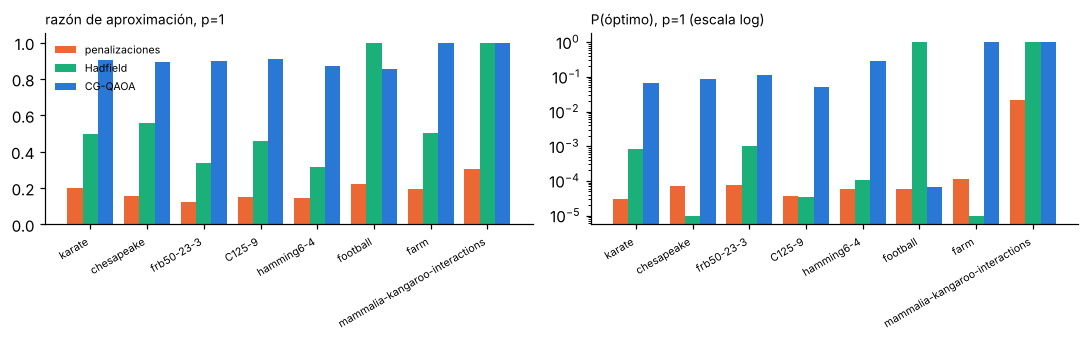

In [6]:
R = {}
for fn in ('../results/cg_qaoa_sub.json', '../results/cg_qaoa_full.json'):
    try: R.update(json.load(open(fn)))
    except FileNotFoundError: pass
rows = []
for nm, r in R.items():
    for p in (1, 2):
        if f'p{p}' not in r: continue
        d = r[f'p{p}']
        rows.append((nm, p, d['penalty']['p_feas'], d['penalty']['ratio'], d['hadfield']['ratio'], d['cg_qvar']['ratio'],
                     d['penalty']['p_opt'], d['hadfield']['p_opt'], d['cg_qvar']['p_opt'], d['prep_qvar_alone']['p_opt']))
print(f"{'instancia':32s} p  factib.pen | razón: pen   Hadf   CG   | P(opt): pen    Hadf    CG     clás.A_q")
for x in rows: print(f"{x[0]:32s} {x[1]}  {x[2]:9.2f}  | {x[3]:9.2f} {x[4]:6.2f} {x[5]:5.2f} | {x[6]:9.4f} {x[7]:7.4f} {x[8]:6.3f} {x[9]:8.3f}")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
names = [x[0].replace('-sub18', '') for x in rows if x[1] == 1]; xs = np.arange(len(names)); w = 0.27
for i, (lab, col, idx) in enumerate([('penalizaciones', '#eb6834', 3), ('Hadfield', '#1baf7a', 4), ('CG-QAOA', '#2a78d6', 5)]):
    ax[0].bar(xs + (i-1)*w, [x[idx] for x in rows if x[1] == 1], w, label=lab, color=col)
for i, (lab, col, idx) in enumerate([('penalizaciones', '#eb6834', 6), ('Hadfield', '#1baf7a', 7), ('CG-QAOA', '#2a78d6', 8)]):
    ax[1].bar(xs + (i-1)*w, [max(x[idx], 1e-5) for x in rows if x[1] == 1], w, label=lab, color=col)
ax[0].set_title('razón de aproximación, p=1', loc='left', fontsize=9); ax[1].set_title('P(óptimo), p=1 (escala log)', loc='left', fontsize=9)
ax[1].set_yscale('log')
for a in ax: a.set_xticks(xs); a.set_xticklabels(names, rotation=30, ha='right', fontsize=7)
ax[0].legend(fontsize=7, frameon=False); plt.tight_layout(); plt.show()

## 5. La ventaja cuántica medible: amplificación frente a muestreo clásico

Con un oráculo de umbral $|x|\ge t$, con $t$ igual al mejor valor conocido de QOBLIB, $k$ rondas de amplificación sobre $A_q$ usan $2k+1$ preparaciones. Muestrear $A_q$ de forma clásica necesita $1/P$ en promedio. La simulación de vector de estado coincide con $\sin^2((2k+1)\theta)$. **No incluimos** el costo del oráculo de umbral (un contador de Hamming), que es polinomial.

instancia                         q    P(prep)   clásico 1/P   cuántico (2k+1)/éxito   ahorro
karate-sub18                     0.5  4.88e-04         2048                    71.0    28.8x
karate-sub18                     0.9  3.49e-02           29                     9.1     3.1x
chesapeake-sub18                 0.5  1.71e-03          585                    37.1    15.8x
chesapeake-sub18                 0.9  4.30e-02           23                     7.1     3.3x
frb50-23-3-sub18                 0.5  1.46e-03          683                    41.0    16.7x
frb50-23-3-sub18                 0.9  4.26e-02           23                     7.1     3.3x
C125-9-sub18                     0.5  2.44e-04         4096                   101.0    40.6x
C125-9-sub18                     0.9  3.14e-02           32                     9.0     3.5x
hamming6-4-sub18                 0.5  9.77e-04         1024                    51.0    20.1x
hamming6-4-sub18                 0.9  6.97e-02           14          

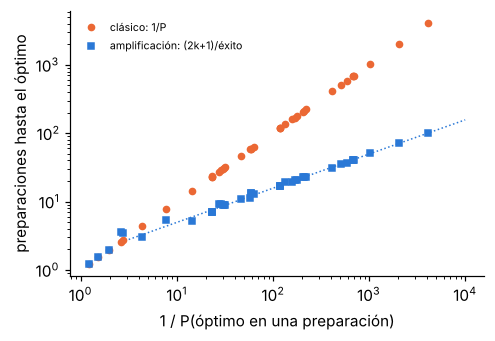

In [7]:
print(f"{'instancia':32s}  q    P(prep)   clásico 1/P   cuántico (2k+1)/éxito   ahorro")
pts = []
for nm, r in R.items():
    for a in r.get('amplification', []):
        pts.append((a['P_prep'], a['classical_samples'], a['quantum_prep_calls']))
        if a['q'] in (0.5, 0.9):
            print(f"{nm:32s} {a['q']:.1f}  {a['P_prep']:.2e}  {a['classical_samples']:11.0f}   {a['quantum_prep_calls']:21.1f}   {a['classical_samples']/a['quantum_prep_calls']:5.1f}x")
pts = np.array(pts)
fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.loglog(1/pts[:, 0], pts[:, 1], 'o', color='#eb6834', ms=4, label='clásico: 1/P')
ax.loglog(1/pts[:, 0], pts[:, 2], 's', color='#2a78d6', ms=4, label='amplificación: (2k+1)/éxito')
xx = np.logspace(0.5, 4, 50); ax.loglog(xx, (np.pi/2)*np.sqrt(xx), ':', color='#2a78d6', lw=1)
ax.set_xlabel('1 / P(óptimo en una preparación)'); ax.set_ylabel('preparaciones hasta el óptimo'); ax.legend(fontsize=7, frameon=False)
plt.tight_layout(); plt.show()

## 6. Hacia el hardware

Costo en `ibm_fez` (CZ tras transpilar con `optimization_level=3`) y predicción con su modelo de ruido. La preparación sola y el QAOA con penalizaciones p=1 caben en el hardware actual; el CG-QAOA p=1 todavía no. Con un ruido así, comparamos lo que se puede ejecutar hoy: **muestrear $A_q$** frente al **QAOA con penalizaciones p=1** (la estrategia de la submission de QAOA de IBM a QOBLIB). Medimos las muestras crudas y también con **reparación voraz**, el post-procesamiento clásico que usa esa submission.

In [8]:
from qiskit import transpile, QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeFez
fake = FakeFez()
pen_lam, pen_x = res['penalty'][1]['lam'], res['penalty'][1]['x']
cg_x = res['cg'][1]['x']
def degeneracy_order(N, n):          # cada vértice tiene <= degeneración vecinos anteriores -> menos controles
    rem = set(range(n)); seq = []
    while rem:
        v = min(rem, key=lambda u: (len(N[u] & rem), u)); seq.append(v); rem.remove(v)
    return seq[::-1]
order_deg = degeneracy_order(g.N, n)
circuits = {
    'A_q (muestreo)': prep_circuit(n, g.N, order, q1),
    'A_q orden degeneración': prep_circuit(n, g.N, order_deg, 0.95),
    'QAOA penalizaciones p=1': penalty_qaoa(n, E, pen_lam, [pen_x[0]], [pen_x[1]]),
    'CG-QAOA p=1': cg_qaoa(n, g.N, order, q1, [cg_x[0]], [cg_x[1]]),
}
circuits['A_q (muestreo)'].measure_all(); circuits['A_q orden degeneración'].measure_all()
isa = {}
for k, qc in circuits.items():
    isa[k] = transpile(qc, fake, optimization_level=3, seed_transpiler=1)
    print(f"{k:26s} CZ={isa[k].count_ops().get('cz', 0):6d}  profundidad={isa[k].depth()}")

A_q (muestreo)             CZ=   794  profundidad=1807
A_q orden degeneración     CZ=   341  profundidad=745
QAOA penalizaciones p=1    CZ=   171  profundidad=332


CG-QAOA p=1                CZ=  7183  profundidad=17440


In [9]:
def repair(bits):
    x = [int(c) for c in bits[::-1]][:n]; S = {v for v in range(n) if x[v]}
    while True:                                   # quitar el vértice con más conflictos
        bad = {v: len(g.N[v] & S) for v in S if g.N[v] & S}
        if not bad: break
        S.remove(max(bad, key=bad.get))
    for v in order:                               # completar de forma voraz
        if not (g.N[v] & S): S.add(v)
    return len(S)
def evaluate(counts, label):
    shots = sum(counts.values()); feas = best = 0; popt = 0; best_rep = 0
    for b, c in counts.items():
        b = b.replace(' ', '')[-n:]; x = [int(ch) for ch in b[::-1]]
        ok = all(not (x[u] and x[v]) for u, v in E); s = sum(x)
        feas += c*ok; popt += c*(ok and s == g.opt); best = max(best, s if ok else 0); best_rep = max(best_rep, repair(b))
    print(f'{label:36s} factibles={feas/shots:.3f}  P(óptimo)={popt/shots:.4f}  mejor crudo={best}  mejor reparado={best_rep}  (óptimo {g.opt})')
RUN_NOISY_SIM = False      # True: re-simulate (A_q noisy simulation takes ~15 s per shot on a laptop CPU)
if RUN_NOISY_SIM:
    noisy = AerSimulator.from_backend(fake)
    for k in ('QAOA penalizaciones p=1', 'A_q (muestreo)'):
        evaluate(noisy.run(isa[k], shots=60, seed_simulator=7).result().get_counts(), 'ruido FakeFez | ' + k)
else:   # precomputed with experiments/cg_qaoa_noisy_prediction.py (penalty: optimised p=1 parameters; A_q: q=0.95)
    D = json.load(open('../results/cg_qaoa_noisy_karate.json'))
    for k, lab in (('penalty', 'QAOA penalizaciones p=1'), ('A', 'A_q grado-bajo-primero, q=0.95'), ('A_degeneracy', 'A_q orden degeneración, q=0.95')):
        if k not in D: continue
        print(f"[{lab}: {D[k]['cz']} CZ en FakeFez, {sum(D[k]['counts'].values())} mediciones]")
        evaluate(D[k]['counts'], 'ruido FakeFez | ' + lab)
    for lab, o in (('grado-bajo-primero', order), ('degeneración', order_deg)):
        m = g.metrics(prep_biased(g, o, 0.95)); print(f"referencia ideal A_q {lab} (q=0.95): factibles=1.000  P(óptimo)={m['p_opt']:.4f}  razón={m['ratio']:.3f}")

[QAOA penalizaciones p=1: 171 CZ en FakeFez, 1000 mediciones]
ruido FakeFez | QAOA penalizaciones p=1 factibles=0.346  P(óptimo)=0.0000  mejor crudo=9  mejor reparado=10  (óptimo 10)
[A_q grado-bajo-primero, q=0.95: 794 CZ en FakeFez, 180 mediciones]
ruido FakeFez | A_q grado-bajo-primero, q=0.95 factibles=0.200  P(óptimo)=0.0000  mejor crudo=9  mejor reparado=10  (óptimo 10)
[A_q orden degeneración, q=0.95: 341 CZ en FakeFez, 100 mediciones]
ruido FakeFez | A_q orden degeneración, q=0.95 factibles=0.490  P(óptimo)=0.1900  mejor crudo=10  mejor reparado=10  (óptimo 10)
referencia ideal A_q grado-bajo-primero (q=0.95): factibles=1.000  P(óptimo)=0.0299  razón=0.869


referencia ideal A_q degeneración (q=0.95): factibles=1.000  P(óptimo)=0.5987  razón=0.934


**Lectura de la predicción.** Con el ruido actual, la preparación pierde buena parte de su factibilidad ideal (100 %), porque cada CZ cuenta. El **orden de degeneración** reduce los controles y casi divide a la mitad los CZ. Ojo: en `karate-sub18` ese orden hace que la voraz clásica ya encuentre el óptimo, así que su alta $P(\text{óptimo})$ ideal **no** es mérito cuántico. En hardware actual, el objetivo realista es medir cuánta factibilidad y calidad sobreviven frente al QAOA con penalizaciones. La ventaja cuántica (amplificación) requiere circuitos más profundos y llegará con corrección de errores.

### Ejecutar en IBM Quantum

Pon `RUN_HARDWARE = True` y la ruta a tu archivo de API key. `RUN_CG = True` agrega el CG-QAOA p=1, que es experimental: con miles de CZ se espera que quede en el piso de ruido.

In [10]:
RUN_HARDWARE = False
RUN_CG = False
API_KEY_FILE = 'apikey_personal.json'
JOB_ID = None                      # para recuperar un job ya enviado

if RUN_HARDWARE or JOB_ID:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    service = QiskitRuntimeService(channel='ibm_cloud', token=json.load(open(API_KEY_FILE))['apikey'])
    keys = ['A_q orden degeneración', 'A_q (muestreo)', 'QAOA penalizaciones p=1'] + (['CG-QAOA p=1'] if RUN_CG else [])
    if JOB_ID:
        job = service.job(JOB_ID)
    else:
        backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n)
        pubs = [transpile(circuits[k], backend, optimization_level=3, seed_transpiler=1) for k in keys]
        for k, c in zip(keys, pubs): print(backend.name, k, 'CZ =', c.count_ops().get('cz', 0))
        sampler = Sampler(mode=backend)
        sampler.options.dynamical_decoupling.enable = True
        sampler.options.twirling.enable_gates = True
        job = sampler.run(pubs, shots=8000); print('job_id:', job.job_id())
    for k, pub in zip(keys, job.result()):
        evaluate(pub.data.meas.get_counts(), 'HARDWARE | ' + k)
else:
    print('Hardware desactivado (RUN_HARDWARE = False).')

Hardware desactivado (RUN_HARDWARE = False).


## 7. Conclusiones

- **El CG-QAOA es factible por construcción.** Las condiciones negadas sustituyen a las penalizaciones: no hay que ajustar $\lambda$ y nunca se gastan muestras en soluciones inválidas.
- **A la misma profundidad supera al QAOA con penalizaciones** en todas las instancias: razón ~0.9 contra ~0.2. **Frente a Hadfield** gana en 4 de 6 subinstancias. En `football` el $q$ variacional colapsa a 1 (la solución voraz) y Hadfield encuentra el óptimo; acotar o barrer $q$ es una mejora pendiente.
- **La ventaja cuántica genuina** está en el número de preparaciones: la amplificación necesita $\approx(\pi/2)/\sqrt{P}$ frente a $1/P$ del muestreo clásico de la misma distribución (15×–41× menos con $q=0.5$; 2.7×–7× con el mejor $q$ de cada lado). A igual costo, el CG-QAOA empata con el muestreo clásico a $p=1$ y lo supera entre 1.3× y 2.3× a $p=2$.
- **Hardware hoy.** Con el modelo de ruido de `ibm_fez`, la preparación (~800 CZ) conserva solo ~20 % de factibilidad y el QAOA con penalizaciones (171 CZ) ~35 %; ninguno ve el óptimo en las mediciones simuladas. El orden de degeneración reduce los CZ a la mitad. La demostración en hardware sirve para medir cuánto sobrevive, no para probar la ventaja.
- **Límites.** No hay ventaja frente a resolvedores clásicos de MIS en estos tamaños. Cada capa del CG-QAOA es más costosa en compuertas que una capa con penalizaciones (requiere $A$, $A^\dagger$ y una reflexión de $n$ qubits), así que en el hardware actual solo es viable ejecutar $A_q$. La reducción de compuertas por ZX-calculus del paper y el hardware tolerante a fallos son el camino para las capas completas.